Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 26.1.2
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Simple Linear Regression Model Trained Successfully!

Slope (Coefficient): 0.4132382936645491
Intercept: -0.35666804105655303

First 10 Predictions:
[1.58555194 0.34583706 2.49467619 1.50290428 1.62687577 0.2631894
 1.13098982 1.75084726 1.50290428 1.2549613 ]
Plot shapes — x: (30,) y_test: (30,) predictions: (30,)


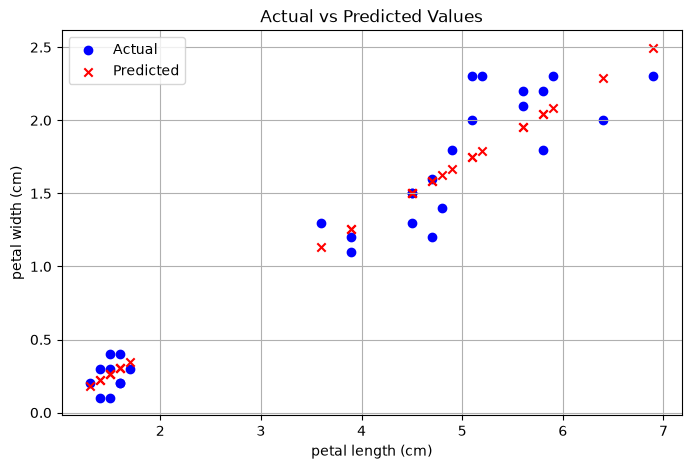

Model Evaluation
---------------------------
Mean Absolute Error (MAE): 0.16818126256563326
Mean Squared Error (MSE): 0.045604284097661846
R² Score: 0.9282562958836972


In [2]:
## Simple linear regression model.

# Install required libraries
%pip install pandas scikit-learn matplotlib

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Load the Iris dataset from scikit-learn
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Simple Linear Regression on Iris
# Use petal length to predict petal width
feature_columns = ["petal length (cm)"]
target_column = "petal width (cm)"

if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found in dataset")
if not all(col in df.columns for col in feature_columns):
    raise ValueError(f"Required feature column(s) {feature_columns} not found in dataset")

X = df[feature_columns]
y = df[target_column]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Simple Linear Regression Model Trained Successfully!")

# Model parameters
print("\nSlope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

# Predict values
predictions = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(predictions[:10])

# Plot actual vs predicted values
# Ensure x is 1D (DataFrame -> Series) to avoid shape errors
x_vals = X_test.iloc[:, 0] if hasattr(X_test, 'iloc') else X_test
print('Plot shapes — x:', getattr(x_vals, 'shape', None), 'y_test:', getattr(y_test, 'shape', None), 'predictions:', getattr(predictions, 'shape', None))
plt.figure(figsize=(8, 5))
plt.scatter(x_vals, y_test, color='blue', label='Actual')
plt.scatter(x_vals, predictions, color='red', marker='x', label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.grid(True)
plt.show()



# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model Evaluation")
print("---------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

In [2]:
import streamlit as st
print(st.__version__)

1.58.0


In [ ]:
import streamlit as st
import pandas as pd
from sklearn.linear_model import LinearRegression

# -----------------------------
# Sample Training Data
# -----------------------------
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 92, 95, 98],
    "Score": [35, 40, 45, 50, 60, 68, 75, 82, 90, 96]
}

df = pd.DataFrame(data)

# Features and Target
X = df[["Study_Hours", "Attendance"]]
y = df["Score"]

# Train the model
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# Streamlit App
# -----------------------------
st.title("Student Score Prediction")

st.write("Enter student details below:")

study_hours = st.number_input(
    "Study Hours",
    min_value=0.0,
    max_value=24.0,
    value=5.0
)

attendance = st.number_input(
    "Attendance (%)",
    min_value=0,
    max_value=100,
    value=80
)

if st.button("Predict Score"):

    prediction = model.predict([[study_hours, attendance]])

    st.success(f"Predicted Score: {prediction[0]:.2f}")